# **Intro to XGBoost**



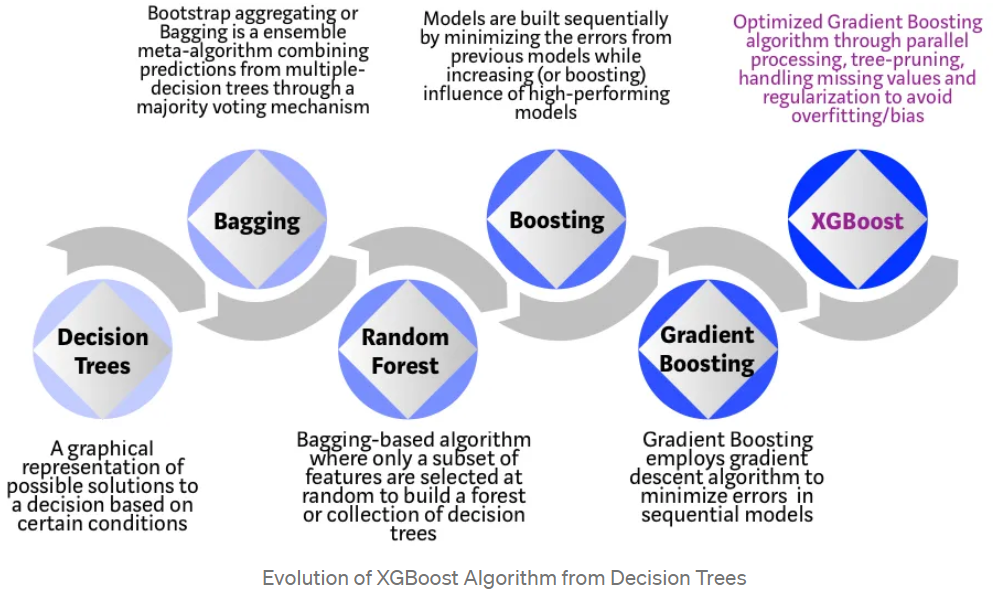

**AdaBoost**

La matematica de estos algoritmos es muy compleja, para entender mejor como funciona, recomiendo investigar el funcionamiento del AdaBoost, que fue el primer algoritmo de Boosting que salio. XGBoost es una mejora del Adaboost, y el CatBoost es una mejora del algoritmo XGBoost.

**Funcionamiento de XGBoost**

1. **Árboles de Decisión:**  
   XGBoost se basa en la construcción de árboles de decisión. Estos árboles son la base sobre la cual se construyen modelos más complejos.

2. **Bagging (Bootstrap Aggregation):**  
   Inicialmente, se generan múltiples árboles de decisión entrenándolos sobre subconjuntos aleatorios de los datos. Luego, se combinan sus predicciones mediante un mecanismo de votación para obtener un resultado más estable y robusto.

3. **Random Forest Mejorado:**  
   A partir de la idea del bagging, se construye un ensamble de árboles (Random Forest). Sin embargo, en este contexto no se limita únicamente a una votación simple: se aprovecha la diversidad de los árboles, de modo que algunos se desempeñen mejor en ciertos subconjuntos de datos y otros en diferentes situaciones, contribuyendo a un modelo global más preciso.

4. **Boosting:**  
   A diferencia de un Random Forest, en el boosting los árboles se entrenan de forma secuencial en lugar de paralela.  
   - **Boosting:** Se construyen modelos de forma secuencial, donde cada nuevo árbol se enfoca en corregir los errores de los anteriores.  

5. **Gradient Boosting:** Esta técnica optimiza el proceso de corrección de errores mediante el uso de gradientes, es decir, cada árbol se crea para minimizar la función de pérdida residual del conjunto de árboles ya entrenados.




**Valores SHAP**

XGBoost integra de forma nativa la capacidad de calcular valores SHAP a través de su implementación del algoritmo Tree SHAP. Esto se consigue utilizando el método predict con el parámetro **pred_contribs=True**, lo que devuelve la contribución de cada característica en la predicción del modelo.

**Rendimiento**

XGBoost es especialmente conocido por su rendimiento en competiciones de ciencia de datos y es ampliamente utilizado en la industria debido a su eficiencia y efectividad.

**Referencias**

This is a complex method. The explanation of the algorithm is out of the scope of this brief intro. We will explain just how to use the package utilities to get a working model.

For a small intro on **XGBoost** check:

- https://towardsdatascience.com/https-medium-com-vishalmorde-xgboost-algorithm-long-she-may-rein-edd9f99be63d
- https://towardsdatascience.com/getting-started-with-xgboost-in-scikit-learn-f69f5f470a97
- https://www.datacamp.com/community/tutorials/xgboost-in-python
- https://www.kaggle.com/stuarthallows/using-xgboost-with-scikit-learn

The base of the Boosting algorithms is however simple. Check **AdaBoost** (`sklearn.ensemble.AdaBoostClassifier`) to know one of the first boosting algorithms. AdaBoost has just 4 hyperparameters, so it is really easy to tune and understand, instead of the tens of parameters in XGBoost.


### **BONUS: Best algorithm for tabular data: CatBoost (as of feb-2021)**

If you want to go straitgh to the real high end of ML algorithms for tabular data (as of feb-2021), take a look al CatBoost:

https://affine.medium.com/catboost-a-new-game-of-machine-learning-72a7dcea0ac4

https://towardsdatascience.com/catboost-demystified-8b0b538bfa31

https://www.youtube.com/watch?v=mUGAA02fGuw&ab_channel=BhaveshBhatt





## **XGBoost for Regression**

### **Load dataset**

In [ ]:
from sklearn.datasets import fetch_openml
# Cargar el dataset Boston desde OpenML
dataset = fetch_openml(name='boston', version=1, as_frame=True)

In [ ]:
print(dataset.DESCR)

**Author**:   
**Source**: Unknown - Date unknown  
**Please cite**:   

The Boston house-price data of Harrison, D. and Rubinfeld, D.L. 'Hedonic
prices and the demand for clean air', J. Environ. Economics & Management,
vol.5, 81-102, 1978.   Used in Belsley, Kuh & Welsch, 'Regression diagnostics
...', Wiley, 1980.   N.B. Various transformations are used in the table on
pages 244-261 of the latter.
Variables in order:
CRIM     per capita crime rate by town
ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
INDUS    proportion of non-retail business acres per town
CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
NOX      nitric oxides concentration (parts per 10 million)
RM       average number of rooms per dwelling
AGE      proportion of owner-occupied units built prior to 1940
DIS      weighted distances to five Boston employment centres
RAD      index of accessibility to radial highways
TAX      full-value property-tax rate per $10

In [ ]:
print(dataset.data.shape)
print(dataset.target.shape)

(506, 13)
(506,)


### **Optional: Convert to dataframe for better readability**

In [ ]:
import pandas as pd

df_features = pd.DataFrame(data=dataset.data)
df_target = pd.DataFrame(dataset.target)
df = pd.concat([df_features, df_target], axis=1)
df.columns = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD',
       'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

In [ ]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


### **Preprocess dataset**

In [ ]:
# split in features and target
X = dataset.data
y = dataset.target

In [ ]:
from sklearn.model_selection import train_test_split
#Split in train and test subsets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

### **Define and fit XGBoost model**

In [ ]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(objective="reg:squarederror", enable_categorical=True, random_state=1)
xgb_model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=1, ...)

### **Make predictions and evaluate model**

In [ ]:
y_pred = xgb_model.predict(X_test)

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error

mse=mean_squared_error(y_test, y_pred)
print(np.sqrt(mse))

2.845164694900871


In [ ]:
print(xgb.__version__)

2.1.4


In [ ]:
# Obtener los valores SHAP (Tree SHAP) para el conjunto de prueba
# El último valor de cada fila corresponde al término de sesgo (bias)
# Convertir X_test a DMatrix, que es requerido por Booster.predict
dtest = xgb.DMatrix(X_test, enable_categorical=True)
shap_values = xgb_model.get_booster().predict(dtest, pred_contribs=True)
print("Shape de los valores SHAP:", shap_values.shape)

Shape de los valores SHAP: (102, 14)


In [ ]:
# Mostrar los valores SHAP de la primera instancia
print("Valores SHAP para la primera instancia:")
print(shap_values[0])

Valores SHAP para la primera instancia:
[ 0.03004759 -0.05999527  1.1113158  -0.02880627  0.5374531  -0.03847497
 -0.6029896   0.17349933 -0.20307997  0.7012127   0.02484092 -0.2374566
  3.4198754  22.522253  ]


In [ ]:
# Opcional: Separar contribuciones de características y el bias
contrib_features = shap_values[:, :-1]
bias_term = shap_values[:, -1]
print("\nPrimeras contribuciones de características para la primera instancia:")
print(contrib_features[0])
print("Bias (término de sesgo) (valor base) para la primera instancia:")
print(bias_term[0])
# el valor base se inicializa como la media de la variable objetivo (y) del conjunto de entrenamiento.
# Es decir, es la predicción que se haría si no se dispusiera de ninguna información adicional de las características


Primeras contribuciones de características para la primera instancia:
[ 0.03004759 -0.05999527  1.1113158  -0.02880627  0.5374531  -0.03847497
 -0.6029896   0.17349933 -0.20307997  0.7012127   0.02484092 -0.2374566
  3.4198754 ]
Bias (término de sesgo) (valor base) para la primera instancia:
22.522253


## **XGBoost for Binary Classification**

### **Load dataset**

In [ ]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
X = cancer.data
y = cancer.target


In [ ]:
print(X.shape)
print(y.shape)

(569, 30)
(569,)


In [ ]:
print(cancer.DESCR)

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

    :Number of Instances: 569

    :Number of Attributes: 30 numeric, predictive attributes and the class

    :Attribute Information:
        - radius (mean of distances from center to points on the perimeter)
        - texture (standard deviation of gray-scale values)
        - perimeter
        - area
        - smoothness (local variation in radius lengths)
        - compactness (perimeter^2 / area - 1.0)
        - concavity (severity of concave portions of the contour)
        - concave points (number of concave portions of the contour)
        - symmetry
        - fractal dimension ("coastline approximation" - 1)

        The mean, standard error, and "worst" or largest (mean of the three
        worst/largest values) of these features were computed for each image,
        resulting in 30 features.  For instance, field 0 is Mean Radi

### **Preprocess dataset**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

### **Define and fit a XGBoost model**

In [ ]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(objective="binary:logistic", random_state=1)
xgb_model.fit(X_train, y_train)


XGBClassifier(random_state=1)

In [ ]:
from copy import deepcopy
xgb_model_binary = deepcopy(xgb_model)

### **Make predictions and evaluate model**

In [ ]:
y_pred = xgb_model.predict(X_test)

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=4))
print(accuracy_score(y_test, y_pred))

[[14  0  0]
 [ 1 14  1]
 [ 0  0  6]]
              precision    recall  f1-score   support

           0     0.9333    1.0000    0.9655        14
           1     1.0000    0.8750    0.9333        16
           2     0.8571    1.0000    0.9231         6

    accuracy                         0.9444        36
   macro avg     0.9302    0.9583    0.9406        36
weighted avg     0.9503    0.9444    0.9441        36

0.9444444444444444


## **XGBoost for Multiclass Classification**

### **Load dataset**

In [ ]:
from sklearn.datasets import load_wine

wine = load_wine()
X = wine.data
y = wine.target


In [ ]:
print(X.shape)
print(y.shape)

(178, 13)
(178,)


In [ ]:
print(wine.DESCR)

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

    :Number of Instances: 178 (50 in each of three classes)
    :Number of Attributes: 13 numeric, predictive attributes and the class
    :Attribute Information:
 		- Alcohol
 		- Malic acid
 		- Ash
		- Alcalinity of ash  
 		- Magnesium
		- Total phenols
 		- Flavanoids
 		- Nonflavanoid phenols
 		- Proanthocyanins
		- Color intensity
 		- Hue
 		- OD280/OD315 of diluted wines
 		- Proline

    - class:
            - class_0
            - class_1
            - class_2
		
    :Summary Statistics:
    
    ============================= ==== ===== ======= =====
                                   Min   Max   Mean     SD
    ============================= ==== ===== ======= =====
    Alcohol:                      11.0  14.8    13.0   0.8
    Malic Acid:                   0.74  5.80    2.34  1.12
    Ash:                          1.36  3.23    2.36  0.27
    Alcalinity of Ash:            1

### **Preprocess dataset**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

### **Define and fit a XGBoost model**

In [ ]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(objective="multi:softprob", random_state=1)
xgb_model.fit(X_train, y_train)


XGBClassifier(objective='multi:softprob', random_state=1)

### **Make predictions and evaluate model**

In [ ]:
y_pred = xgb_model.predict(X_test)

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=4))
print(accuracy_score(y_test, y_pred))

[[14  0  0]
 [ 1 14  1]
 [ 0  0  6]]
              precision    recall  f1-score   support

           0     0.9333    1.0000    0.9655        14
           1     1.0000    0.8750    0.9333        16
           2     0.8571    1.0000    0.9231         6

    accuracy                         0.9444        36
   macro avg     0.9302    0.9583    0.9406        36
weighted avg     0.9503    0.9444    0.9441        36

0.9444444444444444


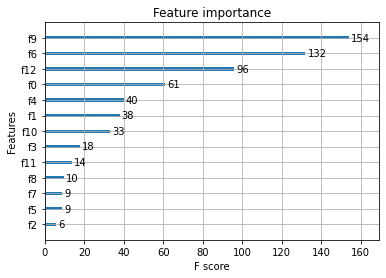

In [ ]:
xgb.plot_importance(xgb_model)

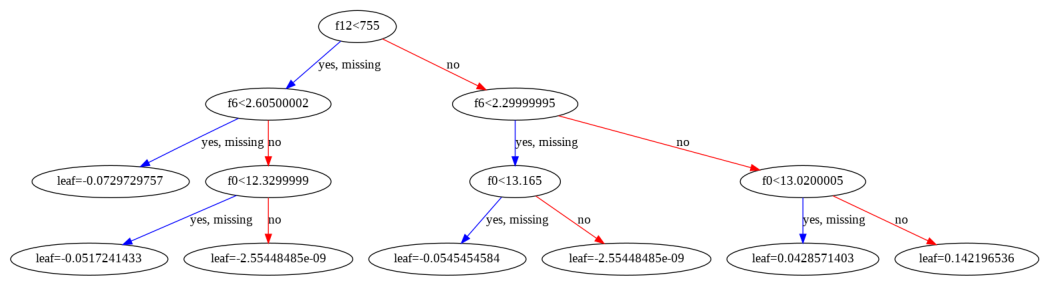

In [ ]:
import matplotlib.pyplot as plt

fig, axis = plt.subplots(1,1, figsize=(20,5))
xgb.plot_tree(booster=xgb_model, num_trees=0, ax=axis)

## **BONUS: Compute AUC ROC**

### **Compute `roc_auc_score`**

The `sklearn.metrics.roc_auc_score` function can also be used for multi-class classification:

- `ovo` (one-vs-one) computes the average AUC of all possible pairwise combinations of classes.
- `ovr` (one-vs-rest) computes the AUC of each class against the rest.

For AUC ROC, we need to predict class probabilities, not just the assigned class.
So, use method `predict_proba` (instead of `predict`):

In [ ]:
y_scores = xgb_model.predict_proba(X_test)


In [ ]:
print(y_scores.shape)
print(y_scores[0:3])

(36, 3)
[[0.9960459  0.00190371 0.00205039]
 [0.00605203 0.01086135 0.9830866 ]
 [0.04258848 0.9439985  0.01341296]]


In [ ]:
from sklearn.metrics import roc_auc_score

print(roc_auc_score(y_test, y_scores, multi_class='ovr'))

0.9989583333333334


### **Plot ROC curves**

For an explanation on the intrepretation of ROC curves and AUC, you can check for example:

https://medium.com/hiredscore-engineering/7-things-you-should-know-about-roc-auc-b4389ea2b2e3

/usr/local/lib/python3.7/dist-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_roc_curve is deprecated; Function :func:`plot_roc_curve` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: :meth:`sklearn.metric.RocCurveDisplay.from_predictions` or :meth:`sklearn.metric.RocCurveDisplay.from_estimator`.
  warnings.warn(msg, category=FutureWarning)


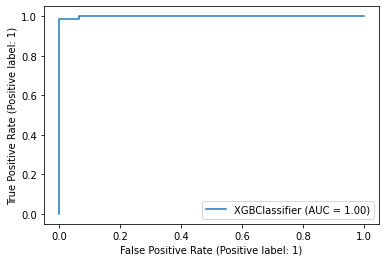

In [ ]:
# plot_roc_curve just works for binary classification, so, useless in this problem
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(xgb_model_binary, X_test, y_test)
plt.show()

ROC curves are typically used in binary classification to study the output of a classifier. In order to extend ROC curve and ROC area to multi-label classification, it is necessary to binarize the output.

In [ ]:
import pandas as pd

y_test_onehot = pd.get_dummies(y_test)
y_test_onehot.head()

,0,1,2
0,1,0,0
1,0,0,1
2,0,1,0
3,1,0,0
4,0,1,0


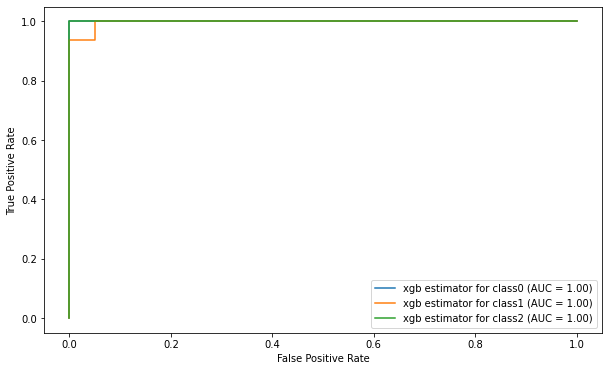

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import auc, RocCurveDisplay, roc_curve

fig, (ax1) = plt.subplots(1, 1, figsize=(10, 6))

# plot ROC for class0:
fpr, tpr, thresholds = roc_curve(y_test_onehot[0], y_scores[:,0]) # or: y_test_onehot.iloc[:,0]
roc_auc = auc(fpr, tpr)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='xgb estimator for class0')
display.plot(ax1)
# plot ROC for class1:
fpr, tpr, thresholds = roc_curve(y_test_onehot[1], y_scores[:,1]) # or: y_test_onehot.iloc[:,0]
roc_auc = auc(fpr, tpr)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='xgb estimator for class1')
display.plot(ax1)
# plot ROC for class2:
fpr, tpr, thresholds = roc_curve(y_test_onehot[2], y_scores[:,2]) # or: y_test_onehot.iloc[:,0]
roc_auc = auc(fpr, tpr)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='xgb estimator for class2')
display.plot(ax1)
# plt.show()

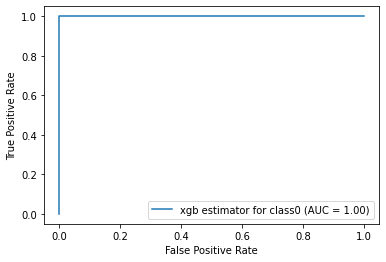

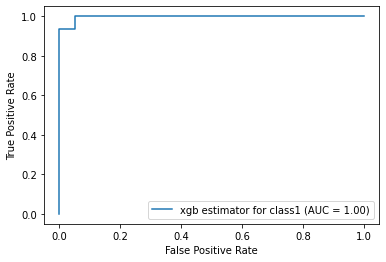

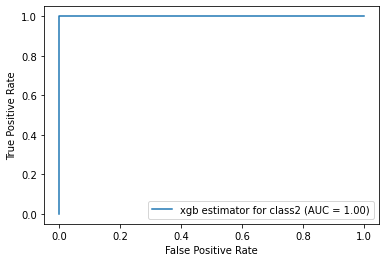

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test_onehot[0], y_scores[:,0]) # or: y_test_onehot.iloc[:,0]
roc_auc = auc(fpr, tpr)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='xgb estimator for class0')
display.plot()
# plot ROC for class1:
fpr, tpr, thresholds = roc_curve(y_test_onehot[1], y_scores[:,1]) # or: y_test_onehot.iloc[:,0]
roc_auc = auc(fpr, tpr)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='xgb estimator for class1')
display.plot()
# plot ROC for class2:
fpr, tpr, thresholds = roc_curve(y_test_onehot[2], y_scores[:,2]) # or: y_test_onehot.iloc[:,0]
roc_auc = auc(fpr, tpr)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='xgb estimator for class2')
display.plot()